In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
old = pd.read_csv("old.csv")
new = pd.read_csv("new.csv")

In [45]:
old.drop(columns= ['SSTA_Rolling_Mean', 'TSA_Rolling_Mean',
       'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12'], inplace= True)

new.drop(columns= ['Date', 'Date_Year', 'Date_Month'], inplace= True)
new.rename(columns={'Depth_m': 'Depth'}, inplace=True)

OLD shape : (6112, 36)
NEW shape : (19727, 39)


,Statistic,OLD,NEW
0,Count,6112.000000,19727.000000
1,Mean,2.795220,9.366153
2,Median,0.000000,0.250000
3,Std,9.634113,19.680361
4,Min,0.000000,0.000000
5,Max,100.000000,100.000000


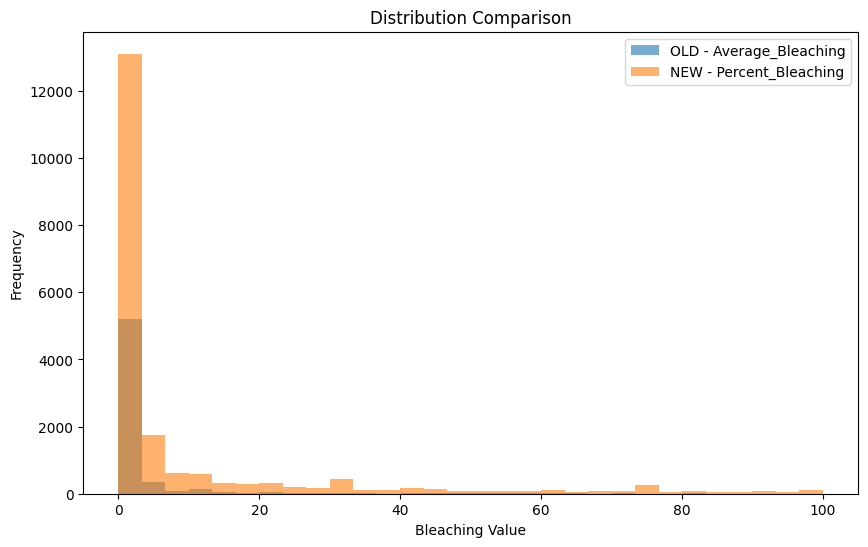

/tmp/ipykernel_132819/2559612622.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


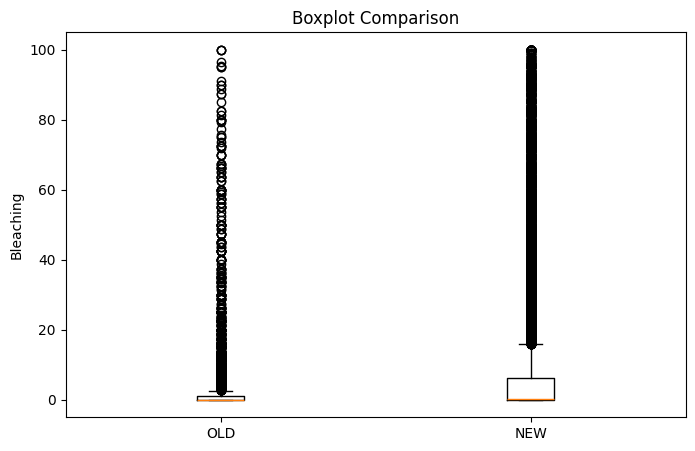

,OLD Missing,NEW Missing
Average_Bleaching,0.0,NaN
ClimSST,0.0,0.0
Cyclone_Frequency,NaN,0.0
Depth,0.0,238.0
Distance_to_Shore,NaN,0.0
Latitude_Degrees,0.0,0.0
Longitude_Degrees,0.0,0.0
Percent_Bleaching,NaN,0.0
SSTA,0.0,0.0
SSTA_DHW,0.0,0.0


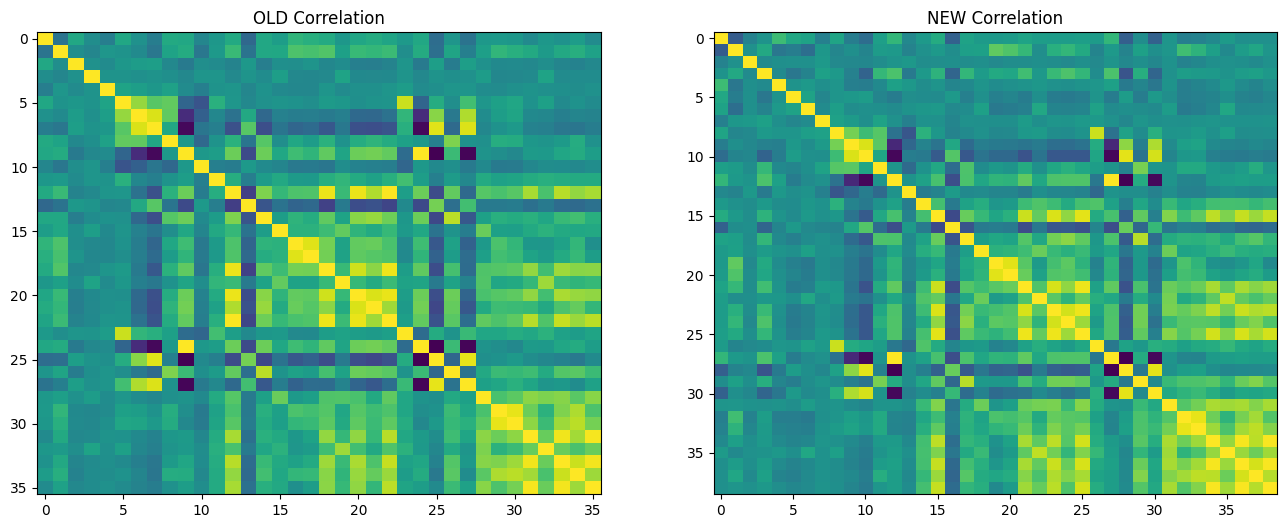


OLD target unique values:
Average_Bleaching
0.00     3914
0.25      254
1.00      213
0.50      184
1.25      125
0.75      114
5.00      108
2.50       95
10.00      68
2.00       59
1.50       54
6.25       48
3.75       43
1.75       41
7.50       35
2.25       32
3.00       30
12.50      29
15.00      26
3.25       25
Name: count, dtype: int64

NEW target unique values:
Percent_Bleaching
0.00      9657
0.25       548
1.00       491
5.50       482
0.50       408
5.00       302
1.25       292
0.75       254
75.00      223
2.50       222
10.00      207
30.50      170
2.00       149
1.50       126
6.25       110
20.00      109
1.75        99
3.75        96
25.00       91
100.00      81
Name: count, dtype: int64


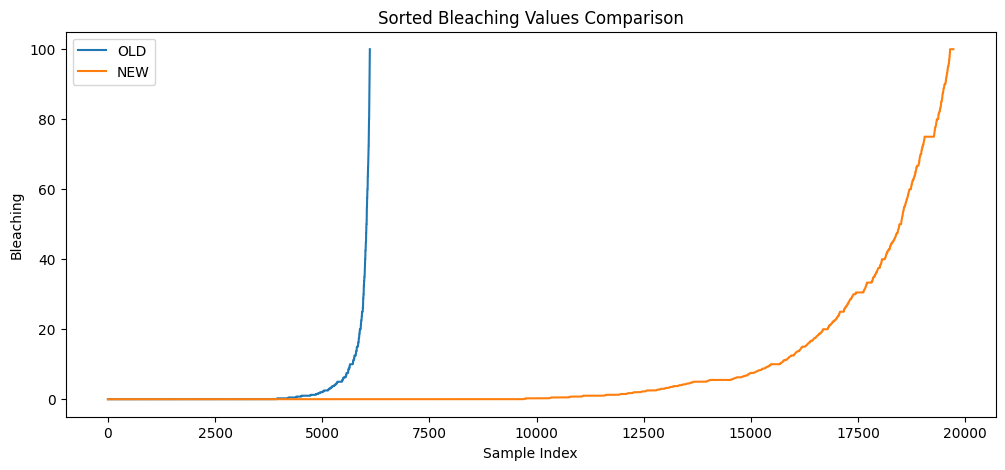


========== SUMMARY ==========

OLD Dataset:
- Mean bleaching : 2.7952
- Std bleaching  : 9.6341
- Max bleaching  : 100.0000

NEW Dataset:
- Mean bleaching : 9.3662
- Std bleaching  : 19.6804
- Max bleaching  : 100.0000



In [46]:
# Target columns
old_y = old["Average_Bleaching"]
new_y = new["Percent_Bleaching"]

print("OLD shape :", old.shape)
print("NEW shape :", new.shape)

# ============================================================
# BASIC STATISTICS
# ============================================================

comparison = pd.DataFrame({
    "Statistic": [
        "Count",
        "Mean",
        "Median",
        "Std",
        "Min",
        "Max"
    ],
    "OLD": [
        old_y.count(),
        old_y.mean(),
        old_y.median(),
        old_y.std(),
        old_y.min(),
        old_y.max()
    ],
    "NEW": [
        new_y.count(),
        new_y.mean(),
        new_y.median(),
        new_y.std(),
        new_y.min(),
        new_y.max()
    ]
})

display(comparison)

# ============================================================
# HISTOGRAM COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    old_y,
    bins=30,
    alpha=0.6,
    label="OLD - Average_Bleaching"
)

plt.hist(
    new_y,
    bins=30,
    alpha=0.6,
    label="NEW - Percent_Bleaching"
)

plt.xlabel("Bleaching Value")
plt.ylabel("Frequency")
plt.title("Distribution Comparison")
plt.legend()

plt.show()

# ============================================================
# BOXPLOT COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

plt.boxplot(
    [old_y.dropna(), new_y.dropna()],
    labels=["OLD", "NEW"]
)

plt.ylabel("Bleaching")
plt.title("Boxplot Comparison")

plt.show()

# ============================================================
# MISSING VALUES
# ============================================================

missing_compare = pd.DataFrame({
    "OLD Missing": old.isnull().sum(),
    "NEW Missing": new.isnull().sum()
})

display(missing_compare)

# ============================================================
# CORRELATION HEATMAP (NUMERIC ONLY)
# ============================================================

old_num = old.select_dtypes(include=np.number)
new_num = new.select_dtypes(include=np.number)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

im1 = ax[0].imshow(old_num.corr(), aspect='auto')
ax[0].set_title("OLD Correlation")

im2 = ax[1].imshow(new_num.corr(), aspect='auto')
ax[1].set_title("NEW Correlation")

plt.show()

# ============================================================
# TARGET VALUE COUNTS
# ============================================================

print("\nOLD target unique values:")
print(old_y.value_counts().head(20))

print("\nNEW target unique values:")
print(new_y.value_counts().head(20))

# ============================================================
# OVERLAY LINE PLOT
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    sorted(old_y.dropna().values),
    label='OLD'
)

plt.plot(
    sorted(new_y.dropna().values),
    label='NEW'
)

plt.title("Sorted Bleaching Values Comparison")
plt.xlabel("Sample Index")
plt.ylabel("Bleaching")
plt.legend()

plt.show()

# ============================================================
# SUMMARY
# ============================================================

print("\n========== SUMMARY ==========")

print(f"""
OLD Dataset:
- Mean bleaching : {old_y.mean():.4f}
- Std bleaching  : {old_y.std():.4f}
- Max bleaching  : {old_y.max():.4f}

NEW Dataset:
- Mean bleaching : {new_y.mean():.4f}
- Std bleaching  : {new_y.std():.4f}
- Max bleaching  : {new_y.max():.4f}
""")

FEATURE COMPARISON

Total OLD features : 36
Total NEW features : 39
Common features    : 35

FEATURES ONLY IN NEW
  1. Cyclone_Frequency
  2. Distance_to_Shore
  3. Percent_Bleaching
  4. Turbidity

FEATURES ONLY IN OLD
  1. Average_Bleaching


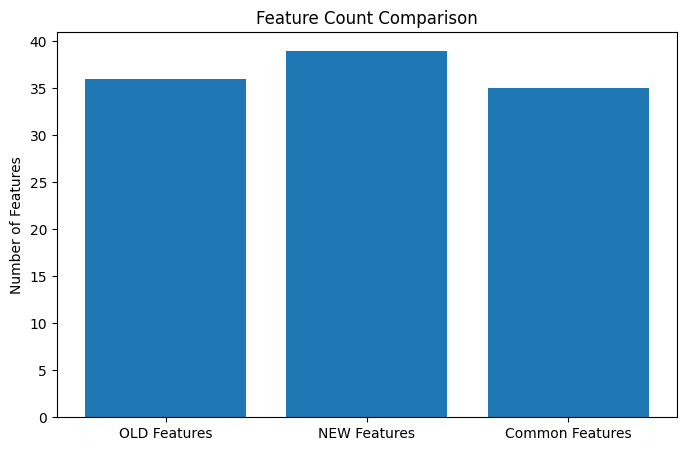


DATA TYPE DIFFERENCES
No datatype differences.

MISSING VALUE DIFFERENCE


,OLD Missing,NEW Missing,Difference
Depth,0.0,238.0,238.0
SSTA_Minimum,3.0,16.0,13.0
ClimSST,0.0,0.0,0.0
Latitude_Degrees,0.0,0.0,0.0
Longitude_Degrees,0.0,0.0,0.0
SSTA_DHW,0.0,0.0,0.0
SSTA,0.0,0.0,0.0
SSTA_DHWMean,0.0,0.0,0.0
SSTA_DHW_Standard_Deviation,0.0,0.0,0.0
SSTA_Frequency,0.0,0.0,0.0


In [47]:
# ============================================================
# FEATURE COMPARISON : OLD vs NEW
# ============================================================

old_features = set(old.columns)
new_features = set(new.columns)

# Features added in NEW
new_only = sorted(list(new_features - old_features))

# Features removed from OLD
old_only = sorted(list(old_features - new_features))

# Common features
common_features = sorted(list(old_features & new_features))

print("="*60)
print("FEATURE COMPARISON")
print("="*60)

print(f"\nTotal OLD features : {len(old_features)}")
print(f"Total NEW features : {len(new_features)}")
print(f"Common features    : {len(common_features)}")

# ============================================================
# FEATURES ONLY IN NEW
# ============================================================

print("\n" + "="*60)
print("FEATURES ONLY IN NEW")
print("="*60)

if len(new_only) == 0:
    print("No new features added.")
else:
    for i, col in enumerate(new_only, 1):
        print(f"{i:>3}. {col}")

# ============================================================
# FEATURES ONLY IN OLD
# ============================================================

print("\n" + "="*60)
print("FEATURES ONLY IN OLD")
print("="*60)

if len(old_only) == 0:
    print("No removed features.")
else:
    for i, col in enumerate(old_only, 1):
        print(f"{i:>3}. {col}")

# ============================================================
# VISUAL BAR CHART
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

categories = [
    "OLD Features",
    "NEW Features",
    "Common Features"
]

counts = [
    len(old_features),
    len(new_features),
    len(common_features)
]

plt.bar(categories, counts)

plt.title("Feature Count Comparison")
plt.ylabel("Number of Features")

plt.show()

# ============================================================
# CHECK DATA TYPE DIFFERENCE
# ============================================================

print("\n" + "="*60)
print("DATA TYPE DIFFERENCES")
print("="*60)

dtype_diff = []

for col in common_features:

    old_type = old[col].dtype
    new_type = new[col].dtype

    if old_type != new_type:
        dtype_diff.append([col, old_type, new_type])

if len(dtype_diff) == 0:
    print("No datatype differences.")
else:
    dtype_df = pd.DataFrame(
        dtype_diff,
        columns=["Feature", "OLD Type", "NEW Type"]
    )

    display(dtype_df)

# ============================================================
# OPTIONAL : MISSING VALUE DIFFERENCE
# ============================================================

print("\n" + "="*60)
print("MISSING VALUE DIFFERENCE")
print("="*60)

missing_compare = pd.DataFrame({
    "OLD Missing": old.isnull().sum(),
    "NEW Missing": new.isnull().sum()
})

missing_compare["Difference"] = (
    missing_compare["NEW Missing"] -
    missing_compare["OLD Missing"]
)

display(
    missing_compare.sort_values(
        by="Difference",
        ascending=False
    )
)